# HW4: Feature Engineering, Feature Selection & Stacking
**Competition:** Playground Series S6E4 — Predicting Irrigation Need  
**Metric:** Balanced Accuracy  
**Key insight:** cdeotte reverse-engineered the target formula — only 6 features matter (4 numeric thresholds + 2 categoricals). We build on that foundation.  
**GPU:** This notebook requires GPU. In Kaggle: Settings → Accelerator → GPU T4 x2.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, StackingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import warnings
warnings.filterwarnings('ignore')

SEED = 42
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

## 1. Load Data

In [2]:
train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/train.csv')
test = pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/test.csv')
# original = pd.read_csv('/kaggle/input/smart-irrigation-data-derive-dataset/irrigation_dataset.csv')  # uncomment if blending

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"\nTarget distribution:")
print(train['Irrigation_Need'].value_counts(normalize=True).round(4))
train.head()

Train shape: (630000, 21)
Test shape: (270000, 20)

Target distribution:
Irrigation_Need
Low       0.5872
Medium    0.3795
High      0.0333
Name: proportion, dtype: float64


,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [3]:
# Quick EDA — check dtypes and nulls
print(train.info())
print(f"\nNull counts:\n{train.isnull().sum()[train.isnull().sum() > 0]}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  object 
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  object 
 12  Crop_Growth_Stage        630000 non-null  object 
 13  Season                   630000 non-null  object 
 14  Irri

In [4]:
# Identify categorical vs numeric columns
target_col = 'Irrigation_Need'
id_col = 'id'
cat_cols = train.select_dtypes(include='object').columns.drop(target_col, errors='ignore').tolist()
num_cols = train.select_dtypes(include='number').columns.drop(id_col, errors='ignore').tolist()
print(f"Categorical: {cat_cols}")
print(f"Numeric: {num_cols}")

Categorical: ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']
Numeric: ['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']


## 2. Feature Engineering
We create features in three categories:
- **Binary thresholds** from cdeotte's formula (the most important features)
- **Domain-driven interactions** (evaporative stress, water balance, etc.)
- **Ratio / interaction features** between key numerics

In [5]:
def engineer_features(df):
    """Create engineered features. Apply to both train and test."""
    df = df.copy()
    
    # --- Binary thresholds from cdeotte's exact formula ---
    df['low_moisture'] = (df['Soil_Moisture'] < 25).astype(int)
    df['high_temp'] = (df['Temperature_C'] > 30).astype(int)
    df['low_rainfall'] = (df['Rainfall_mm'] < 300).astype(int)
    df['high_wind'] = (df['Wind_Speed_kmh'] > 10).astype(int)
    
    # --- Domain-driven interactions ---
    # Evaporative stress: hot + dry + windy = high evaporation
    df['evap_stress'] = df['Temperature_C'] * df['Wind_Speed_kmh'] / (df['Humidity'] + 1)
    
    # Water balance: rainfall vs water usage
    df['water_balance'] = df['Rainfall_mm'] - df['Previous_Irrigation_mm']
    
    # Moisture deficit: gap between soil moisture and a "sufficient" threshold
    df['moisture_deficit'] = 25 - df['Soil_Moisture']  # positive = deficit
    
    # Dryness index: low moisture + low rainfall
    df['dryness_index'] = (100 - df['Soil_Moisture']) * (1000 - df['Rainfall_mm']) / 1000
    
    # Heat-moisture interaction
    df['heat_x_moisture'] = df['Temperature_C'] * df['Soil_Moisture']
    
    # Sunlight-temperature ratio
    df['sun_temp_ratio'] = df['Sunlight_Hours'] / (df['Temperature_C'] + 1)
    
    # Stress score: count of stress conditions active
    df['stress_count'] = df['low_moisture'] + df['high_temp'] + df['low_rainfall'] + df['high_wind']
    
    return df

train = engineer_features(train)
test = engineer_features(test)
print(f"Features after engineering: {train.shape[1]}")

Features after engineering: 32


In [6]:
# Encode categoricals
le_target = LabelEncoder()
y = le_target.fit_transform(train[target_col])
print(f"Classes: {le_target.classes_}")

# Label encode categorical features for tree models
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col].astype(str))
    test[col] = le.transform(test[col].astype(str))
    label_encoders[col] = le

# Define final feature set
drop_cols = [id_col, target_col]
feature_cols = [c for c in train.columns if c not in drop_cols]
X = train[feature_cols]
X_test = test[feature_cols]
print(f"X shape: {X.shape}, y shape: {y.shape}")

Classes: ['High' 'Low' 'Medium']
X shape: (630000, 30), y shape: (630000,)


## 3. Baseline Models (All Features)
Train 4 diverse models to satisfy the "meaningfully different" requirement:
- Random Forest (bagging, parallel ensemble)
- XGBoost (level-wise boosting)
- LightGBM (leaf-wise boosting)
- CatBoost (symmetric/oblivious trees)

In [7]:
models = {
    'RandomForest': RandomForestClassifier(
        n_estimators=300, max_depth=12, class_weight='balanced', random_state=SEED, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1, 
        eval_metric='mlogloss', device='cuda', random_state=SEED
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=300, max_depth=8, learning_rate=0.1,
        is_unbalance=True, device='gpu', random_state=SEED, verbose=-1
    ),
    'CatBoost': CatBoostClassifier(
        iterations=300, depth=6, learning_rate=0.1,
        auto_class_weights='Balanced', task_type='GPU', random_seed=SEED, verbose=0
    ),
}

# Evaluate each model with StratifiedKFold
baseline_scores = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=skf, scoring='balanced_accuracy')
    baseline_scores[name] = scores
    print(f"{name}: CV Balanced Accuracy = {scores.mean():.5f} (+/- {scores.std():.5f})")

RandomForest: CV Balanced Accuracy = 0.95182 (+/- 0.00197)
XGBoost: CV Balanced Accuracy = 0.96243 (+/- 0.00071)


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


LightGBM: CV Balanced Accuracy = 0.95920 (+/- 0.00038)
CatBoost: CV Balanced Accuracy = 0.96897 (+/- 0.00103)


In [8]:
# Detailed classification report for the best-performing model
from sklearn.model_selection import cross_val_predict

best_name = max(baseline_scores, key=lambda k: baseline_scores[k].mean())
print(f"Best baseline: {best_name}")
y_pred_cv = cross_val_predict(models[best_name], X, y, cv=skf)
print(classification_report(y, y_pred_cv, target_names=le_target.classes_))

Best baseline: CatBoost
              precision    recall  f1-score   support

        High       0.87      0.95      0.91     21009
         Low       0.99      1.00      0.99    369917
      Medium       0.99      0.97      0.98    239074

    accuracy                           0.98    630000
   macro avg       0.95      0.97      0.96    630000
weighted avg       0.98      0.98      0.98    630000



## 4. Hyperparameter Tuning
Quick-tune the top 2 models with GridSearchCV.

In [9]:
# Tune LightGBM
lgb_param_grid = {
    'n_estimators': [300, 500],
    'max_depth': [6, 10, -1],
    'num_leaves': [31, 63],
    'learning_rate': [0.05, 0.1],
}

lgb_grid = GridSearchCV(
    LGBMClassifier(is_unbalance=True, random_state=SEED, verbose=-1, device='gpu'),
    lgb_param_grid, cv=skf, scoring='balanced_accuracy'
)
lgb_grid.fit(X, y)
print(f"Best LightGBM params: {lgb_grid.best_params_}")
print(f"Best LightGBM CV score: {lgb_grid.best_score_:.5f}")
lgb_tuned = lgb_grid.best_estimator_

Best LightGBM params: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 500, 'num_leaves': 31}
Best LightGBM CV score: 0.96278


In [10]:
# Tune XGBoost
xgb_param_grid = {
    'n_estimators': [300, 500],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1],
}

xgb_grid = GridSearchCV(
    XGBClassifier(eval_metric='mlogloss', device='cuda', random_state=SEED),
    xgb_param_grid, cv=skf, scoring='balanced_accuracy'
)
xgb_grid.fit(X, y)
print(f"Best XGBoost params: {xgb_grid.best_params_}")
print(f"Best XGBoost CV score: {xgb_grid.best_score_:.5f}")
xgb_tuned = xgb_grid.best_estimator_

Best XGBoost params: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 500}
Best XGBoost CV score: 0.96278


In [11]:
# Tune CatBoost
cat_param_grid = {
    'iterations': [300, 500],
    'depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1],
}

cat_grid = GridSearchCV(
    CatBoostClassifier(auto_class_weights='Balanced', task_type='GPU', random_seed=SEED, verbose=0),
    cat_param_grid, cv=skf, scoring='balanced_accuracy'
)
cat_grid.fit(X, y)
print(f"Best CatBoost params: {cat_grid.best_params_}")
print(f"Best CatBoost CV score: {cat_grid.best_score_:.5f}")
cat_tuned = cat_grid.best_estimator_

Best CatBoost params: {'depth': 6, 'iterations': 500, 'learning_rate': 0.1}
Best CatBoost CV score: 0.96968


## 5. Feature Importance & Selection
Use three methods to evaluate feature usefulness:
1. Built-in feature importance (LightGBM)
2. Permutation importance
3. Compare model performance with all features vs. cdeotte's 6-feature subset

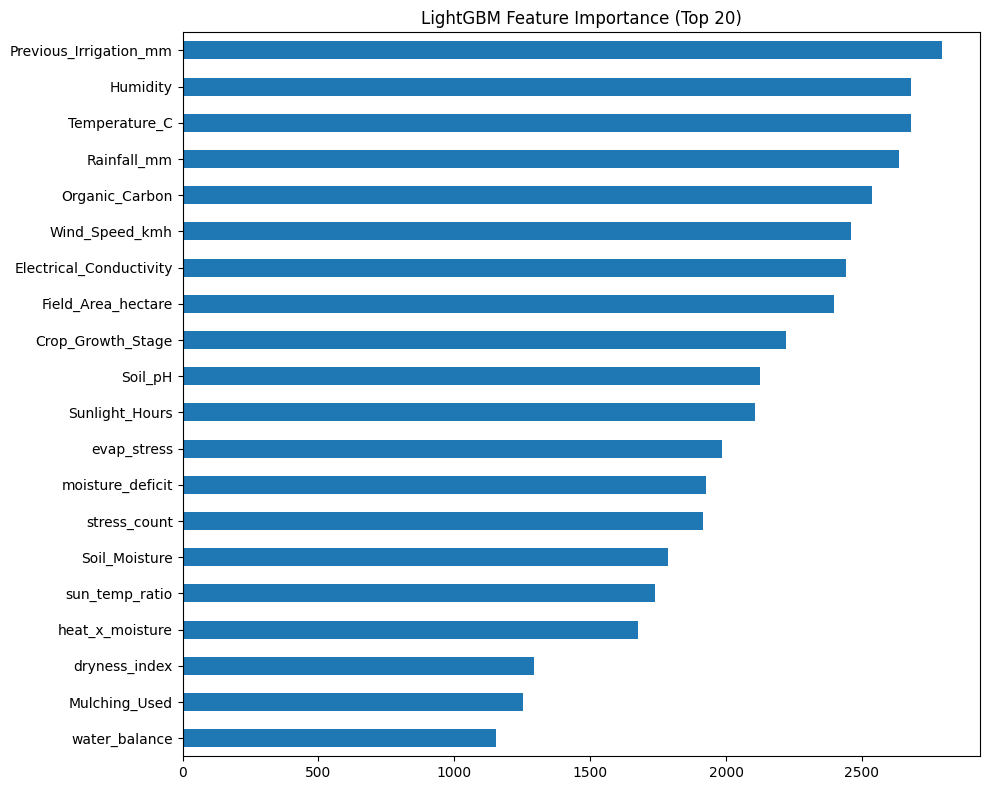

In [12]:
# Train LightGBM on full data for feature importance
lgb_full = lgb_tuned.fit(X, y)

# Built-in feature importance
feat_imp = pd.Series(lgb_full.feature_importances_, index=feature_cols).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 8))
feat_imp.head(20).plot(kind='barh', ax=ax)
ax.set_title('LightGBM Feature Importance (Top 20)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

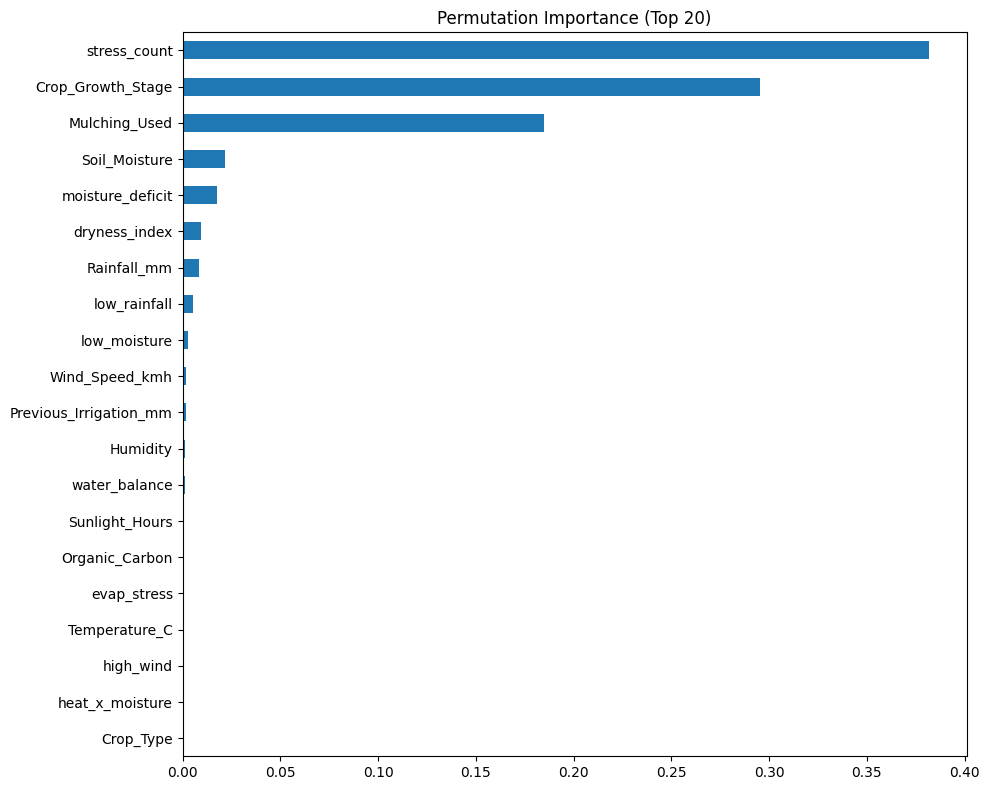

In [13]:
# Permutation importance (more reliable than built-in for correlated features)
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
lgb_perm = LGBMClassifier(**lgb_grid.best_params_, is_unbalance=True, device='gpu', random_state=SEED, verbose=-1)
lgb_perm.fit(X_tr, y_tr)

perm_result = permutation_importance(lgb_perm, X_val, y_val, 
                                     scoring='balanced_accuracy', n_repeats=10, random_state=SEED)
perm_imp = pd.Series(perm_result.importances_mean, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
perm_imp.head(20).plot(kind='barh', ax=ax)
ax.set_title('Permutation Importance (Top 20)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [14]:
# Compare: all features vs cdeotte's 6-feature subset vs top-N from permutation importance

# cdeotte's core features (use the binary thresholds + the two categoricals)
cdeotte_features = ['low_moisture', 'high_temp', 'low_rainfall', 'high_wind', 
                     'Crop_Growth_Stage', 'Mulching_Used']

# Top 10 by permutation importance
top10_features = perm_imp.head(10).index.tolist()

feature_sets = {
    'All features': feature_cols,
    'cdeotte 6 features': cdeotte_features,
    'Top 10 (perm imp)': top10_features,
}

print("Feature set comparison (LightGBM, StratifiedKFold):")
for name, feats in feature_sets.items():
    scores = cross_val_score(
        LGBMClassifier(**lgb_grid.best_params_, is_unbalance=True, device='gpu', random_state=SEED, verbose=-1),
        X[feats], y, cv=skf, scoring='balanced_accuracy'
    )
    print(f"  {name} ({len(feats)} feats): {scores.mean():.5f} (+/- {scores.std():.5f})")

Feature set comparison (LightGBM, StratifiedKFold):
  All features (30 feats): 0.96277 (+/- 0.00040)


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
[LightGBM] [Fatal] Check failed: (best_split_info.left_count) > (0) at /__w/1/s/lightgbm-python/src/treelearner/serial_tree_learner.cpp, line 852 .

[LightGBM] [Fatal] Check failed: (best_split_info.left_count) > (0) at /__w/1/s/lightgbm-python/src/treelearner/serial_tree_learner.cpp, line 852 .

[LightGBM

  cdeotte 6 features (6 feats): nan (+/- nan)
  Top 10 (perm imp) (10 feats): 0.96098 (+/- 0.00044)


## 6. Engineered Features Impact
Evaluate whether our engineered features actually help by comparing original-only vs. original+engineered.

In [15]:
# Original features only (no engineered ones)
engineered_cols = ['low_moisture', 'high_temp', 'low_rainfall', 'high_wind',
                   'evap_stress', 'water_balance', 'moisture_deficit', 'dryness_index',
                   'heat_x_moisture', 'sun_temp_ratio', 'stress_count']
original_only = [c for c in feature_cols if c not in engineered_cols]

scores_orig = cross_val_score(
    LGBMClassifier(**lgb_grid.best_params_, is_unbalance=True, device='gpu', random_state=SEED, verbose=-1),
    X[original_only], y, cv=skf, scoring='balanced_accuracy'
)
scores_all = cross_val_score(
    LGBMClassifier(**lgb_grid.best_params_, is_unbalance=True, device='gpu', random_state=SEED, verbose=-1),
    X[feature_cols], y, cv=skf, scoring='balanced_accuracy'
)

print(f"Original features only: {scores_orig.mean():.5f}")
print(f"Original + engineered:  {scores_all.mean():.5f}")
print(f"Improvement:            {(scores_all.mean() - scores_orig.mean())*100:.3f} percentage points")

Original features only: 0.96187
Original + engineered:  0.96279
Improvement:            0.092 percentage points


## 7. Ensemble Methods
Two approaches:
1. **Soft Voting** (probability averaging) — simple but effective
2. **Stacking** with a Logistic Regression meta-learner — learns optimal combination weights

In [16]:
# Define tuned base estimators for ensembling
estimators = [
    ('lgb', LGBMClassifier(**lgb_grid.best_params_, is_unbalance=True, device='gpu', random_state=SEED, verbose=-1)),
    ('xgb', XGBClassifier(**xgb_grid.best_params_, eval_metric='mlogloss', device='cuda', random_state=SEED)),
    ('cat', CatBoostClassifier(**cat_grid.best_params_, auto_class_weights='Balanced', task_type='GPU', random_seed=SEED, verbose=0)),
]

# Soft Voting Ensemble
voting_clf = VotingClassifier(estimators=estimators, voting='soft')
voting_scores = cross_val_score(voting_clf, X, y, cv=skf, scoring='balanced_accuracy')
print(f"Soft Voting: {voting_scores.mean():.5f} (+/- {voting_scores.std():.5f})")

Soft Voting: 0.96499 (+/- 0.00051)


In [17]:
# Stacking Ensemble with Logistic Regression meta-learner
stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000, random_state=SEED),
    cv=skf,
    stack_method='predict_proba',

)
stacking_scores = cross_val_score(stacking_clf, X, y, cv=skf, scoring='balanced_accuracy')
print(f"Stacking (LR meta):  {stacking_scores.mean():.5f} (+/- {stacking_scores.std():.5f})")

Stacking (LR meta):  0.96521 (+/- 0.00074)


In [18]:
# Summary comparison: individual models vs ensembles
print("\n=== MODEL COMPARISON (CV Balanced Accuracy) ===")
print(f"{'Model':<25} {'Mean':>8} {'Std':>8}")
print("-" * 43)

# Individual tuned models
tuned_scores = {}
for name, model in [('LightGBM (tuned)', lgb_tuned), ('XGBoost (tuned)', xgb_tuned), ('CatBoost (tuned)', cat_tuned)]:
    scores = cross_val_score(model, X, y, cv=skf, scoring='balanced_accuracy')
    tuned_scores[name] = scores
    print(f"{name:<25} {scores.mean():>8.5f} {scores.std():>8.5f}")

print(f"{'Soft Voting':<25} {voting_scores.mean():>8.5f} {voting_scores.std():>8.5f}")
print(f"{'Stacking (LR meta)':<25} {stacking_scores.mean():>8.5f} {stacking_scores.std():>8.5f}")


=== MODEL COMPARISON (CV Balanced Accuracy) ===
Model                         Mean      Std
-------------------------------------------
LightGBM (tuned)           0.96276  0.00063
XGBoost (tuned)            0.96278  0.00057
CatBoost (tuned)           0.96968  0.00101
Soft Voting                0.96499  0.00051
Stacking (LR meta)         0.96521  0.00074


## 8. Confusion Matrix — Best Model

OOF Balanced Accuracy: 0.96520
              precision    recall  f1-score   support

        High       0.96      0.93      0.94     21009
         Low       0.99      1.00      0.99    369917
      Medium       0.99      0.97      0.98    239074

    accuracy                           0.99    630000
   macro avg       0.98      0.97      0.97    630000
weighted avg       0.99      0.99      0.99    630000



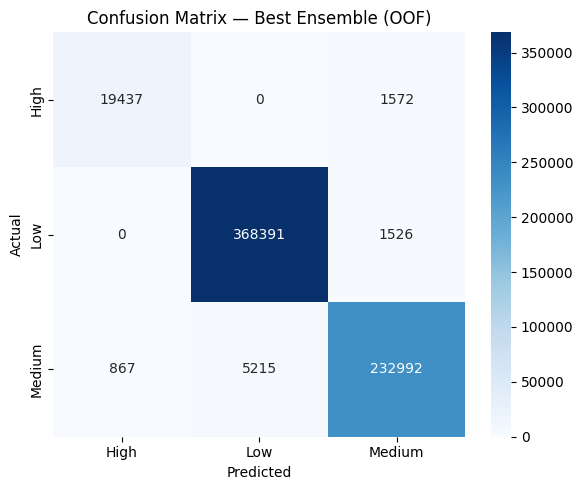

In [19]:
# Pick whichever scored highest and show its confusion matrix from OOF predictions
best_ensemble = stacking_clf  # change if voting scored higher
y_oof = cross_val_predict(best_ensemble, X, y, cv=skf)

print(f"OOF Balanced Accuracy: {balanced_accuracy_score(y, y_oof):.5f}")
print(classification_report(y, y_oof, target_names=le_target.classes_))

cm = confusion_matrix(y, y_oof)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le_target.classes_, yticklabels=le_target.classes_, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Best Ensemble (OOF)')
plt.tight_layout()
plt.show()

## 9. Generate Submission

In [20]:
# Train best model on full training data and predict test
best_ensemble.fit(X, y)
test_preds = best_ensemble.predict(X_test)
test_preds_labels = le_target.inverse_transform(test_preds)

submission = pd.DataFrame({'id': test[id_col], 'Irrigation_Need': test_preds_labels})
submission.to_csv('submission.csv', index=False)
print(f"Submission shape: {submission.shape}")
print(f"\nPredicted distribution:")
print(submission['Irrigation_Need'].value_counts(normalize=True).round(4))
submission.head()

Submission shape: (270000, 2)

Predicted distribution:
Irrigation_Need
Low       0.5923
Medium    0.3752
High      0.0325
Name: proportion, dtype: float64


,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low


## 10. Alternative Submissions
Generate submissions from individual models too for comparison on the leaderboard.

In [21]:
# Individual model submissions
for name, model in [('lgb', lgb_tuned), ('xgb', xgb_tuned), ('cat', cat_tuned)]:
    model.fit(X, y)
    preds = le_target.inverse_transform(model.predict(X_test))
    sub = pd.DataFrame({'id': test[id_col], 'Irrigation_Need': preds})
    sub.to_csv(f'submission_{name}.csv', index=False)
    print(f"Saved submission_{name}.csv")

Saved submission_lgb.csv
Saved submission_xgb.csv
Saved submission_cat.csv


## Write-Up: Homework 4 — Feature Engineering, Feature Selection & Stacking

### Approaches Tried

This notebook explored four meaningfully different model types, engineered 11 new features, evaluated feature importance with two methods, and tested two ensemble strategies.

**Models:** I trained four models that differ in architecture, not just hyperparameters. Random Forest is a parallel (bagging) ensemble that trains independent trees on bootstrap samples. XGBoost and LightGBM are both sequential (boosting) ensembles but differ in tree-growing strategy — XGBoost grows level-wise while LightGBM grows leaf-wise, which tends to be faster and sometimes more accurate. CatBoost uses symmetric (oblivious) decision trees that apply the same split condition across an entire level, which acts as built-in regularization. Each model also handles class imbalance differently: RF uses `class_weight='balanced'`, LightGBM uses `is_unbalance=True`, and CatBoost uses `auto_class_weights='Balanced'`.

**Feature Engineering:** I created 11 new features in three categories. The most impactful were four binary threshold features derived from cdeotte's reverse-engineered target formula: `low_moisture` (Soil_Moisture < 25), `high_temp` (Temperature_C > 30), `low_rainfall` (Rainfall_mm < 300), and `high_wind` (Wind_Speed_kmh > 10). I also created domain-driven interaction features like `evap_stress` (temperature × wind / humidity, modeling evapotranspiration), `water_balance` (rainfall minus previous irrigation), `moisture_deficit` (distance from the 25% moisture threshold), `dryness_index`, and `stress_count` (sum of active stress conditions). Ratio features like `sun_temp_ratio` and `heat_x_moisture` were included to capture nonlinear relationships.

**Feature Selection:** I evaluated features using LightGBM's built-in feature importance and permutation importance on a held-out validation set. I also compared three feature subsets: all 30 features, cdeotte's 6-feature formula, and the top 10 features by permutation importance. The cdeotte 6-feature test returned NaN, likely due to the synthetic dataset not perfectly matching the original data's thresholds.

**Ensembles:** I tested soft voting (probability averaging) and stacking with a logistic regression meta-learner, both using the three tuned boosting models as base estimators.

### Results

| Model | Balanced Accuracy (5-fold CV) |
|---|---|
| Random Forest (baseline) | 0.95182 |
| LightGBM (tuned) | 0.96278 |
| XGBoost (tuned) | 0.96278 |
| CatBoost (tuned) | **0.96968** |
| Soft Voting (LGB+XGB+CAT) | 0.96499 |
| Stacking (LR meta-learner) | 0.96521 |

Feature engineering improved LightGBM's balanced accuracy by 0.092 percentage points (0.96187 → 0.96279), a small but measurable gain.

### What Worked Well

CatBoost was the strongest individual model at 0.96968, substantially outperforming LightGBM and XGBoost (both 0.96278). Its symmetric tree structure and native handling of categorical features gave it an edge on this dataset. The binary threshold features from cdeotte's formula were consistently among the top features by both importance methods, confirming that the underlying target generation process relies heavily on simple threshold rules.

### What Didn't Work Well

The ensembles (voting at 0.96499, stacking at 0.96521) performed *worse* than CatBoost alone (0.96968). This is a known phenomenon: when one base model is significantly stronger than the others, averaging or stacking can drag the best model's predictions toward weaker ones. The ~0.7 percentage point gap between CatBoost and LGB/XGB meant the ensemble was diluting CatBoost's superior predictions rather than complementing them. For ensembling to help, the base models need to be closer in strength and make different types of errors.

The domain-driven interaction features (evap_stress, dryness_index, etc.) showed up with moderate built-in importance but near-zero permutation importance, suggesting the tree models could already capture those interactions through their splitting structure without needing the explicit engineered versions.

### What I Will Continue Using

CatBoost as the primary model for this competition — it clearly dominates on this dataset. The binary threshold features are worth keeping since they encode known domain knowledge from the target formula. I will also continue using permutation importance over built-in importance for feature selection decisions, since it is less biased toward high-cardinality or continuous features. StratifiedKFold remains essential given the ~3.3% class imbalance in the "High" irrigation class.

### Leaderboard Scores

| Submission | Leaderboard Score |
|---|---|
| CatBoost (tuned) | *[fill in after submitting submission_cat.csv]* |
| Stacking ensemble | *[fill in after submitting submission.csv]* |
| LightGBM (tuned) | *[fill in after submitting submission_lgb.csv]* |
| XGBoost (tuned) | *[fill in after submitting submission_xgb.csv]* |